# Exercises for Part 1

## Notes on intensity
$T_{math} = \frac{\text{Compute FLOPS}}{\text{Accelerator FLOPs}}$

NVIDIA H100 can perform about 9.89e14 (~1e15) bfloat16 FLOPs/s while a TPU v6e can perform 9.1e14 FLOPs/s.

Doing 1e12 FLOPs on an H100 will take (roughly) 1e12 / 9.89e14 = 1.01ms and 1e12 / 9.1e14 = 1.1ms on a TPU v6e.

Latency Issue: Tensors have to be transferred from HBM (Hardware Based Memory(?)) to device memory

~1.6 tb/s for TPU v6e
~3.35 tb/s for H100

$T_{comm} = \frac{\text{Bytes to Communicate}}{\text{Communication (Network/Mem Bandwidth) bytes/s}}$

On occasion, communication and operations can be overlapped, giving us upper, lower bounds for time for a set of operations

$T_{lower} = \text{Max}(T_{math}, T_{comm})$ -> parallelized benefit, constrained by slower

$T_{upper} = T_{math} + T_{comm}$ -> no benefit from parallel, combination of all time

if $T_{math} > T_{comm}$, we are compute bound and vice versa, communication bound

Represent with ratio $\text{Arithmetic Intensity} = \frac{\text{Computation FLOPS}}{\text{Comm Bytes}}$

Example of application: TPU max bandwidth os 240 flops/byte so if Arithmetic Intensity lower than that, we will be wasting flops

Ex/ dot product of `x: bf16[N], y: bf16[N] -> z: bf16[1]`: N multiplications, N-1 additions for the algorithm. Each `bf16` entry = 2 8bit bytes so we have to load 2N+2N bytes for `x`, `y` and then write 2 bytes to memory for `z`. Plugging into Arithmetic Intensity, we see that:

$\text{Arith. Intensity} = \frac{(N) + (N-1)}{(2N)+(2N)+2} = \frac{2N-1}{4N+2} \approx \frac{2N}{4N} \approx \frac{1}{2} \text{ as N..}\inf$

0.5 flops/byte is significantly less than the max of 240 flops/byte 

Apparently, dot product is computed on VPU unit specifically which has cap of 7e12 flops/sec per core. VPU still has cap intensity of 3 so dot product remains at ~1/6 perf.

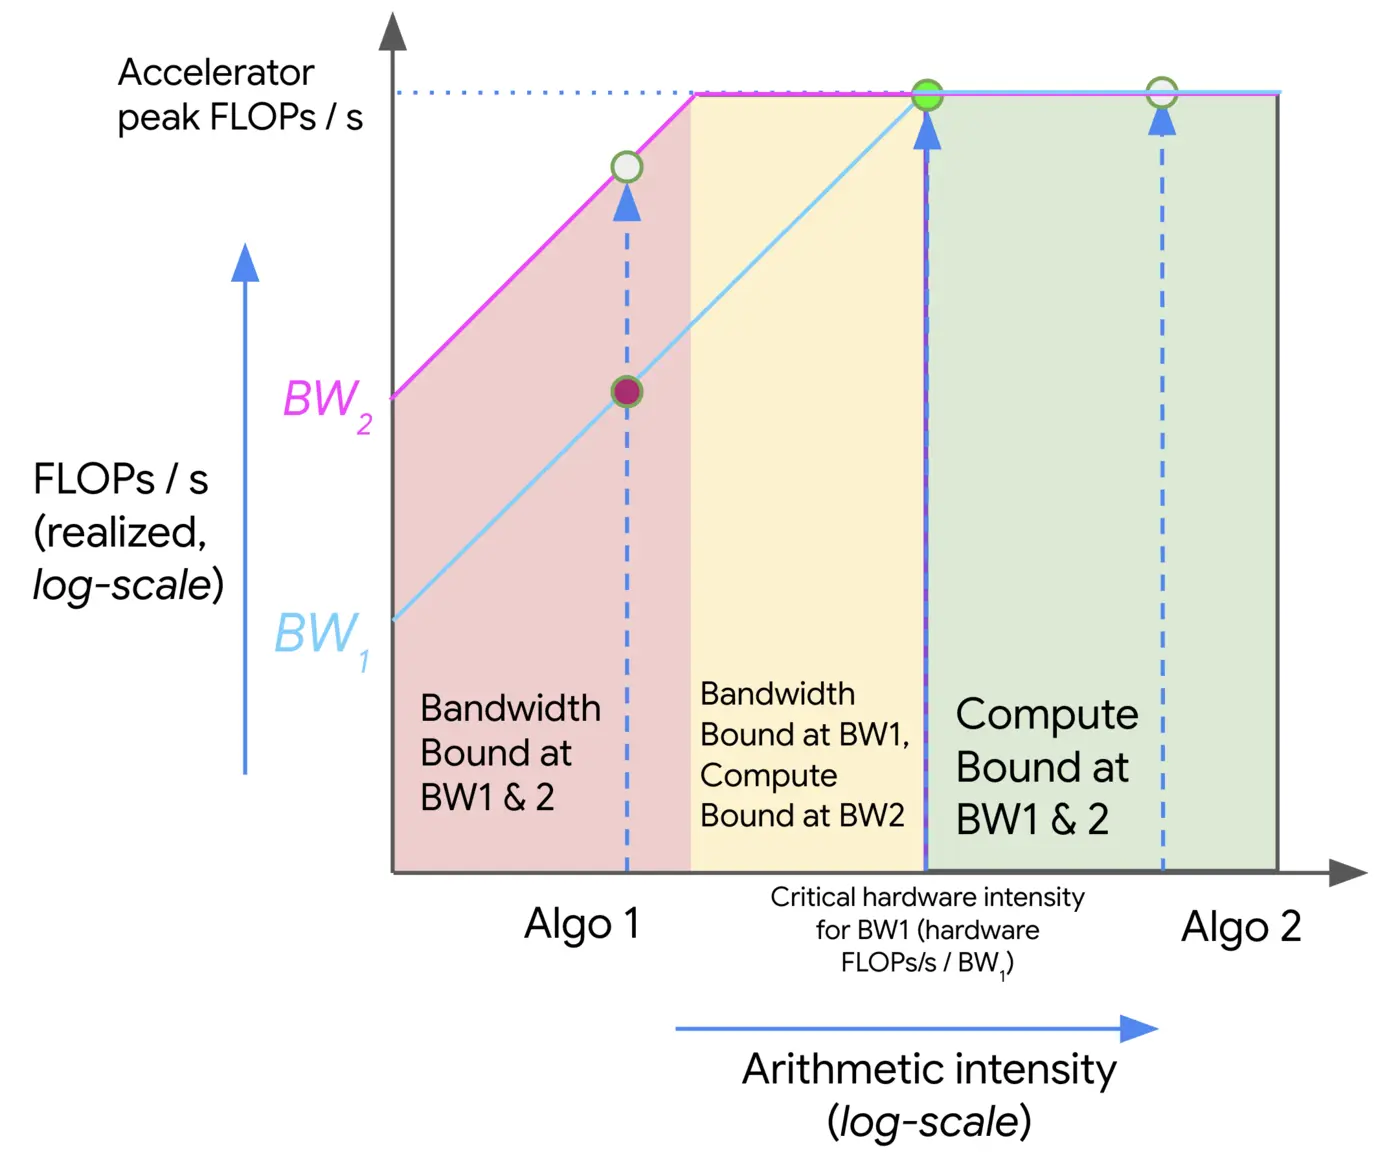

Plot above, different algorithms are constrained differently. The plot is a bit confusing but it's looking at the performance of 2 different algorithms with different bandwidth constraints, BW1 and BW2. Algorithm 1 is bandwidth bound and performs better at higher bandwidths (able to perform at higher flops/s) while Algo 2 is compute bound and can only  really be improved  with more flops/s available on a TPU. 

I think the best way to understand this plot is as two separate ones - the straight line at the top is the peak bandwidth of the TPU. At BW1,2 Algo1 is initially bandiwdth constrained and as BW1,2 increase, Algo1 is able to perform at higher flops/s and becomes more compute constrained. Algo2 isn't bandwidth constrained at all but rather compute constrained in what it can do

### Example of Compute-Intensity Constraint

Oh dear lord it's matmul time. 

`X: bf16[B,D] * Y: bf16[D,F] = Z: bf16[B,F]`

Intensity: `2BDF` flops of operations

Communication (r/w): Load `X: 2BD`, `Y: 2DF`, Write `Z: 2BF`

Assume $B$ small compared to $D,F$: intensity becomes $\frac{2BDF}{2BD+2DF+2BF} \approx \frac{2BDF}{2D+2F+2DF} \approx \frac{BDF}{D+F+DF}$

Assume $D,F$ sufficiently large s.t. ${DF} >> D+F$ at large D,F

Can then say intensity = $\frac{BDF}{DF} \approx B$. With TPU intensity of 240 flops/s, we are compute constrained for $B>240$

Based on assumptions for transformers where $B \approx 1024 \text{ tokens}$ while $D,F >8000$

Changes per tile sizes when large matmul decomposed to smaller on GPU, TPU (hoo boy)

### Example of Constraint for Sharded Matmul

Instead of within-chip communications, what about matrices sharded across chips, where we're constrained by how quickly we're able to communicate shards and results across chips

Also, from here onwards, I'll use "accelerator" as an umbrella term for TPU/GPU, it will be interchangeable for both unless a calculation requires something specific, which I will then specify

Ex/ Large `X: bf16[B,D], Y: bf16[D,F]` split along D on 2 accelerators. Accelerator 1 takes `X: bf16[:, :(D//2)], Y: bf16[:(D//2), :]` while Accelerator 2 takes `X: bf16[:, (D//2):], Y: bf16[(D//2):, :]`. Then, the results from each half (`z_partial: bf16[B,F]`) can be copied to 1 Accelerator and summed for the final result. 

We can copy 4.5e10 bytes/s each direction and 1.97e14 flops per TPU specifically

$T_{math} = \frac{2BDF}{2*1.97e14} = \frac{BDF}{1.97e14}$

$T_{comm} = \frac{2BF}{4.5e10}$

We are compute constrained when $T_{math} > T_{comm} = \frac{BDF}{1.97e14} > \frac{2BF}{4.5e10} = \frac{BDF}{2BF} > \frac{1.97e14}{4.5e10} = \frac{D}{2} > 4377 = D > 8755$

## Practice Questions

### Question 1 [int8 matmul]

Say we want to do the matmul 

$$ X[B,D] \cdot Y[D,F] \rightarrow Z[B,F] $$

in int8 precision (1 byte per parameter) instead of bfloat16 (2 bytes per parameter) since TPUs/GPUs can do matmuls faster in lower precision.

Assume our HBM bandwidth is \( 8.2 \times 10^{11} \) bytes/s and our int8 peak OPs/s is \( 3.94 \times 10^{14} \) (about 2x bfloat16).

1. How many bytes need to be loaded from memory? `BD+DF` loaded
2. How many need to be written back to memory? `BF`
3. How many total OPs are performed? `2BDF` same # but just faster
4. What is the arithmetic intensity? 

$$\frac{2BDF}{BD+DF+BF} \approx \frac{2BDF}{DF} \approx 2B
\newline\text{ We want to understand where this hits the peak for the TPU at} \newline\newline\frac{3.94e14 \text{ int8 ops/s}}{8.2e11 \text{ bytes/s}} \approx 480\text{, so if }2B > 480 = B > 240\text{, we will be constrained. }$$

5. What is a roofline estimate for \( T_{math} \) and \( T_{comms} \)? 

$T_{math} = \frac{\text{flops performed}}{\text{device flops}} = \frac{2BDF}{3.94e14 \text{ops/s}}$

$T_{comms} = \frac{\text{bytes comm}}{\text{device comm}} = \frac{BD+DF+BF}{8.2e11 \text{bytes/s}}$

6. What are reasonable upper and lower bounds for the runtime of the whole operation?

Lower: $\text{Min}(T_{math}, T_{comm})$

Upper: $T_{math} + T_{comm}$

---

### Question 2 [int8 + bf16 matmul]

In practice, we often do different weight vs. activation quantization, so we might store our weights in very low precision but keep activations (and compute) in a higher precision. Say we want to quantize our weights in int8 but keep activations (and compute) in bfloat16. At what batch size do we become compute bound? Assume $( 1.97 \times 10^{14} )$ bfloat16 FLOPs/s.

Hint: this means specifically 

$$ bf16[B, D] \cdot int8[D, F] \rightarrow bf16[B, F] $$ 

where \( B \) is the “batch size”.

Load `2BD`, `DF`, write `2BF` to memory. Even if read is cheaper for int8 matrix, speed would be at bf16 speed of computation with `2BDF` flops.

Assume small B compared to D,F and that $DF >> 2D, DF >> 2F$

$\text{Intensity} = \frac{2BDF}{2BD+DF+2BF} = \frac{2BDF}{2D+DF+2F} \approx \frac{2BDF}{DF} = 2B$

$2B = 240 \rightarrow B=120$, so we are constrained for B > 120.

---

### Question 3

Taking the setup from Question 2, make a roofline plot of peak FLOPs/s vs. \( B \) for 

$$ F = D = 4096 $$ 

and 

$$ F = D = 1024 $$ 

Use the exact number of bytes loaded, not an approximation.

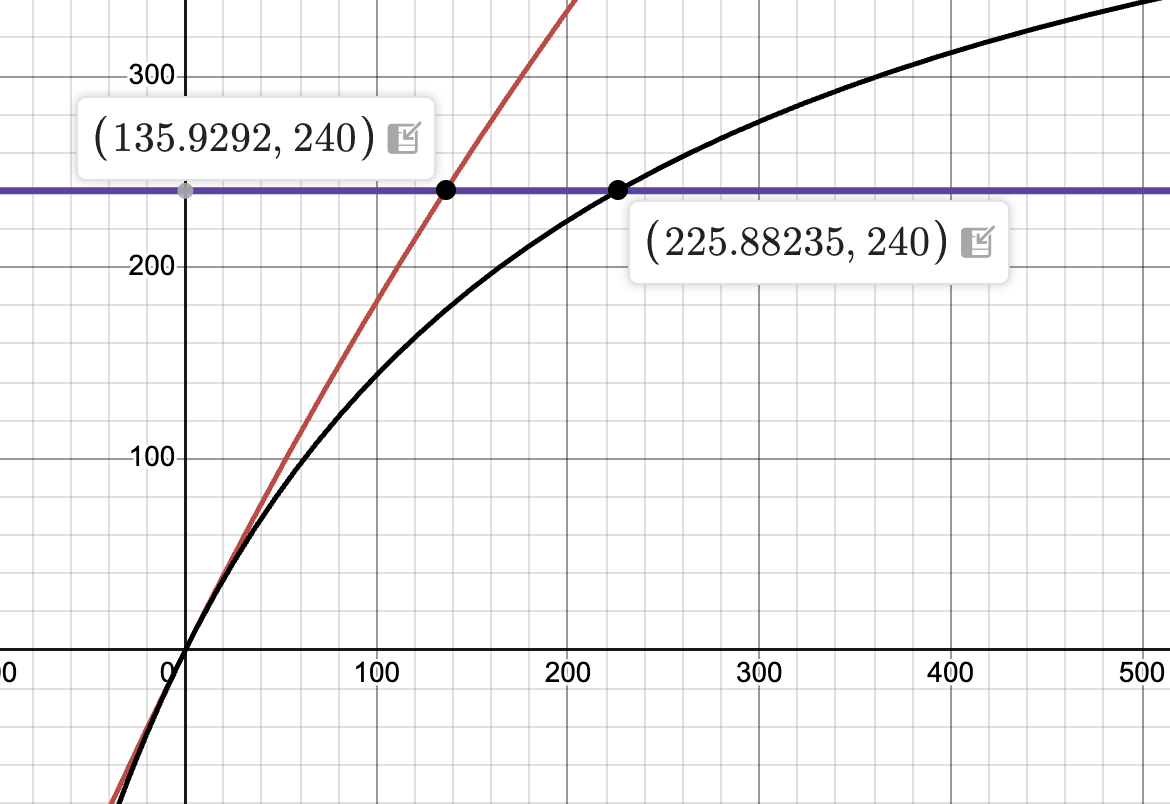

Peak flops are higher for smaller F,D; allows us to load at larger B. Red is F=D=4096, Black is F=D=1024

---

### Question 4

What if we wanted to perform 

$$ int8[B,D] \cdot int8[B,D,F] \rightarrow int8[B,F] $$ 

where we imagine having a different matrix for each batch element. What is the arithmetic intensity of this operation?

Load in `BD`, `BDF` and write `BF`

doing B DxDF products so becomes $B(DF+DF-1) \approx 2BDF$

Intensity $= \frac{2BDF}{BD + BDF + BF} \approx \frac{2BDF}{BDF} \approx 2$, always comms bound

---

### Question 5 [Memory Rooflines for GPUs]

Using the spec sheet provided by NVIDIA for the H100 SXM ([link](https://www.nvidia.com/en-us/data-center/h100/)), calculate the batch size at which a bfloat16 matrix multiplication will become compute-bound. Note that the Tensor Core FLOPs numbers are twice the true value since they’re only achievable with structured sparsity.

BF16 tensor core operates at 1979 tflops $\approx$ 1,979,000,000,000,000 -> 1.9e15 flops/s

Memory bandwidth is 3.35 tb/s $\approx$ 3.35e+12 bytes/s

Therefore, max intensity on the H100 is $\approx \frac{1.9e15 flops/s}{3.4e12 bytes/s} \approx \frac{1.9e3}{3.4} flops/byte \approx 560 flops/byte$

The H100 would be throttled at a batch size of $\approx 560$. Accounting for the true value, the batch size it'll be constrained at will be roughly $280$ (exact value of 295).